In [1]:
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm.notebook import tqdm
import json
import h5py
import os

import warnings
warnings.filterwarnings("ignore")


from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import LocallyIsothermalEOS  
from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS 
from DiscEvolution.eos import DeadZoneEOS 
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code, GasConst, Omega0, AU, Msun  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf
from DiscEvolution.diffusion import TracerDiffusion 
from DiscEvolution.planet_formation import Planets, Bitsch2015Model
from DiscEvolution.constants import *

In [2]:
t_initial = 0.0 * u.Myr
t_initial_yr = t_initial.to(u.yr).value 
t_initial_code = t_initial_yr * yr_code  #Convert to code units

t_final = 0.1 * u.Myr
t_final_yr = t_final.to(u.yr).value 
t_final_code = t_final_yr * yr_code  #Convert to code units

Mdisk = 0.1 * Msun 
Rd = 50.0 # u.AU #where disc starts fading out at 0.1 Myr in order to be at 120 AU at 1Myr
Mstar = 1.0 * u.solMass
Rstar = 2.5 * u.solRad
Tstar = 4000.0 * u.K
mu = 2.4
gamma = 1.0

#Reference Values
Mdot_ref = 1e-8
alpha_SS_DZ = 1e-3
alpha_SS_AZ = 1e-2

In [3]:
R_in = 0.1   # AU
R_out = 1000.0  # AU — must be >> Rd (91 AU) so the spreading front never reaches the boundary
Ncells = 1000
grid = Grid(R_in, R_out, Ncells, spacing='natural')
R = grid.Rc  # AU

In [4]:
star = SimpleStar(M = Mstar.value ,      #Msun
                  R = Rstar.value,       #Rsun
                  T_eff = Tstar.value,   #K
                  age = t_initial_yr)    #yr

In [5]:
e_rad = 0.9 
psi = 1.0
lambda_DW = 1/(2*(1 - e_rad)*(3/psi + 1)) + 1 

In [6]:
# initial guess for Sigma
Sigma_d = Mdisk/(2 * np.pi * (Rd)**2)
#xi = 0.25 * (1 + psi) * (np.sqrt(1 + 4*psi/((lambda_DW - 1) * (psi + 1)**2)) - 1)
xi = 0
Sigma = Sigma_d * (R/Rd)**(xi - gamma) * np.exp(-(R/Rd)**(2 - gamma))

# define an initial disc and gas class to be used later
disc = AccretionDisc(grid, star, eos=None, Sigma=Sigma)
wind_model = HybridWindModel(psi, lambda_DW)

# scale Sigma by current Mtot just in case Sigma is not quite at the correct value to have the desired Mdisk (which often happens)
Mtot = disc.Mtot()
Sigma[:] *= Mdisk / Mtot

In [7]:
eos = DeadZoneEOS(star, psi , Mdot_ref, evolution_model='ionization', alpha_guess=alpha_SS_DZ)
# eos = IrradiatedEOS(star, alpha_t=alpha_SS_DZ, kappa=Zhu2012, psi=psi, e_rad=e_rad, Tmax=1500)
eos.set_grid(grid)
eos.update(0, Sigma)

disc = AccretionDisc(grid,star,eos,Sigma)

In [8]:
eos._psi

1.0

In [9]:
# If you want ot chekc how the solver evolves don't run this cell, skip to the next one. 
from DiscEvolution.solvers import *

psi_value = psi_from_alphaSS_Mdot(eos, disc, wind_model,Mdot_ref, guess=0.001, max_iterations=200, tol = 1e-7)
print(psi_value)

  Final psi: -1.000000e+00
  Final Mdot: 3.954341e-08
  Target Mdot: 1.000000e-08
-0.9999999999999998


In [10]:
# Debug: trace psi and Mdot at each iteration
import importlib, DiscEvolution.solvers as _s; importlib.reload(_s)

psi_test = eos._psi  # reset to initial (0.01) — eos was rebuilt in cell above
#eos_test = IrradiatedEOS(star, alpha_t=alpha_SS_DZ, kappa=Zhu2012, psi=psi_test, e_rad=e_rad, Tmax=1500)
eos_test = DeadZoneEOS(star, psi_test , Mdot_ref, evolution_model='ionization', alpha_guess=alpha_SS_DZ)
eos_test.set_grid(grid)
eos_test.update(0, Sigma)
disc_test = AccretionDisc(grid, star, eos_test, Sigma)
wm_test = HybridWindModel(psi_test, lambda_DW)

print(f"{'iter':>4}  {'psi':>12}  {'Mdot_actual':>14}  {'ratio':>10}")
for i in range(20):
    eos_test._psi = psi_test
    eos_test.update(0, Sigma)
    wm_test._psi = psi_test
    vr = wm_test.viscous_velocity(disc_test)
    Mdot_actual = disc_test.Mdot(vr[0])
    ratio = Mdot_ref / Mdot_actual
    print(f"{i:>4}  {psi_test:>12.4e}  {Mdot_actual:>14.6e}  {ratio:>10.5f}")
    psi_new = (1 + psi_test) * ratio - 1
    psi_test = 0.5 * (psi_new + psi_test)
    psi_test = max(psi_test, 0.0)


iter           psi     Mdot_actual       ratio
   0   -1.0000e+00    3.954341e-08     0.25289
   1    0.0000e+00    7.602031e-08     0.13154
   2    0.0000e+00    7.602031e-08     0.13154
   3    0.0000e+00    7.602031e-08     0.13154
   4    0.0000e+00    7.602031e-08     0.13154
   5    0.0000e+00    7.602031e-08     0.13154
   6    0.0000e+00    7.602031e-08     0.13154
   7    0.0000e+00    7.602031e-08     0.13154
   8    0.0000e+00    7.602031e-08     0.13154
   9    0.0000e+00    7.602031e-08     0.13154
  10    0.0000e+00    7.602031e-08     0.13154
  11    0.0000e+00    7.602031e-08     0.13154
  12    0.0000e+00    7.602031e-08     0.13154
  13    0.0000e+00    7.602031e-08     0.13154
  14    0.0000e+00    7.602031e-08     0.13154
  15    0.0000e+00    7.602031e-08     0.13154
  16    0.0000e+00    7.602031e-08     0.13154
  17    0.0000e+00    7.602031e-08     0.13154
  18    0.0000e+00    7.602031e-08     0.13154
  19    0.0000e+00    7.602031e-08     0.13154


In [11]:
eos = DeadZoneEOS(star, psi_value, Mdot_ref, alpha_guess = alpha_SS_DZ, evolution_model='ionization')

eos.set_grid(grid)
eos.update(0, Sigma)

eos.build_alpha_psi_arrays(
    alpha_active=alpha_SS_AZ,
    alpha_dead = alpha_SS_DZ,
    psi_active= (alpha_SS_DZ * psi_value) / (alpha_SS_AZ),
    psi_dead = psi_value
)

eos.update(0, Sigma)
disc = AccretionDisc(grid, star, eos, Sigma)

ValueError: build_alpha_psi_arrays: psi values must be non-negative

In [ ]:
alpha_dead = alpha_SS_DZ
alpha_active = alpha_SS_AZ
alpha_DW = psi_value * alpha_SS_DZ
psi_dead = psi_value
psi_active = alpha_DW / alpha_SS_AZ
w = 1.0

# One scale height at dead zone radius
H = np.interp(eos._R_dz, eos._R, eos._H)
if not np.isfinite(H) or H <= 0:
    raise ValueError(f"_rebuild_alpha_psi: invalid scale height at R_dz={eos._R_dz} (H={H})")

# Build tanh transition: 0 inside dead zone, 1 in active region
transition = 0.5 * ( 1 + np.tanh((eos._R - eos._R_dz) / (w * H)) )

# Build spatially-varying arrays
alpha_arr = alpha_dead + (alpha_active - alpha_dead) * transition
psi_arr = psi_dead + (psi_active - psi_dead) * transition

eos._alpha_t = alpha_arr
eos._psi = psi_arr

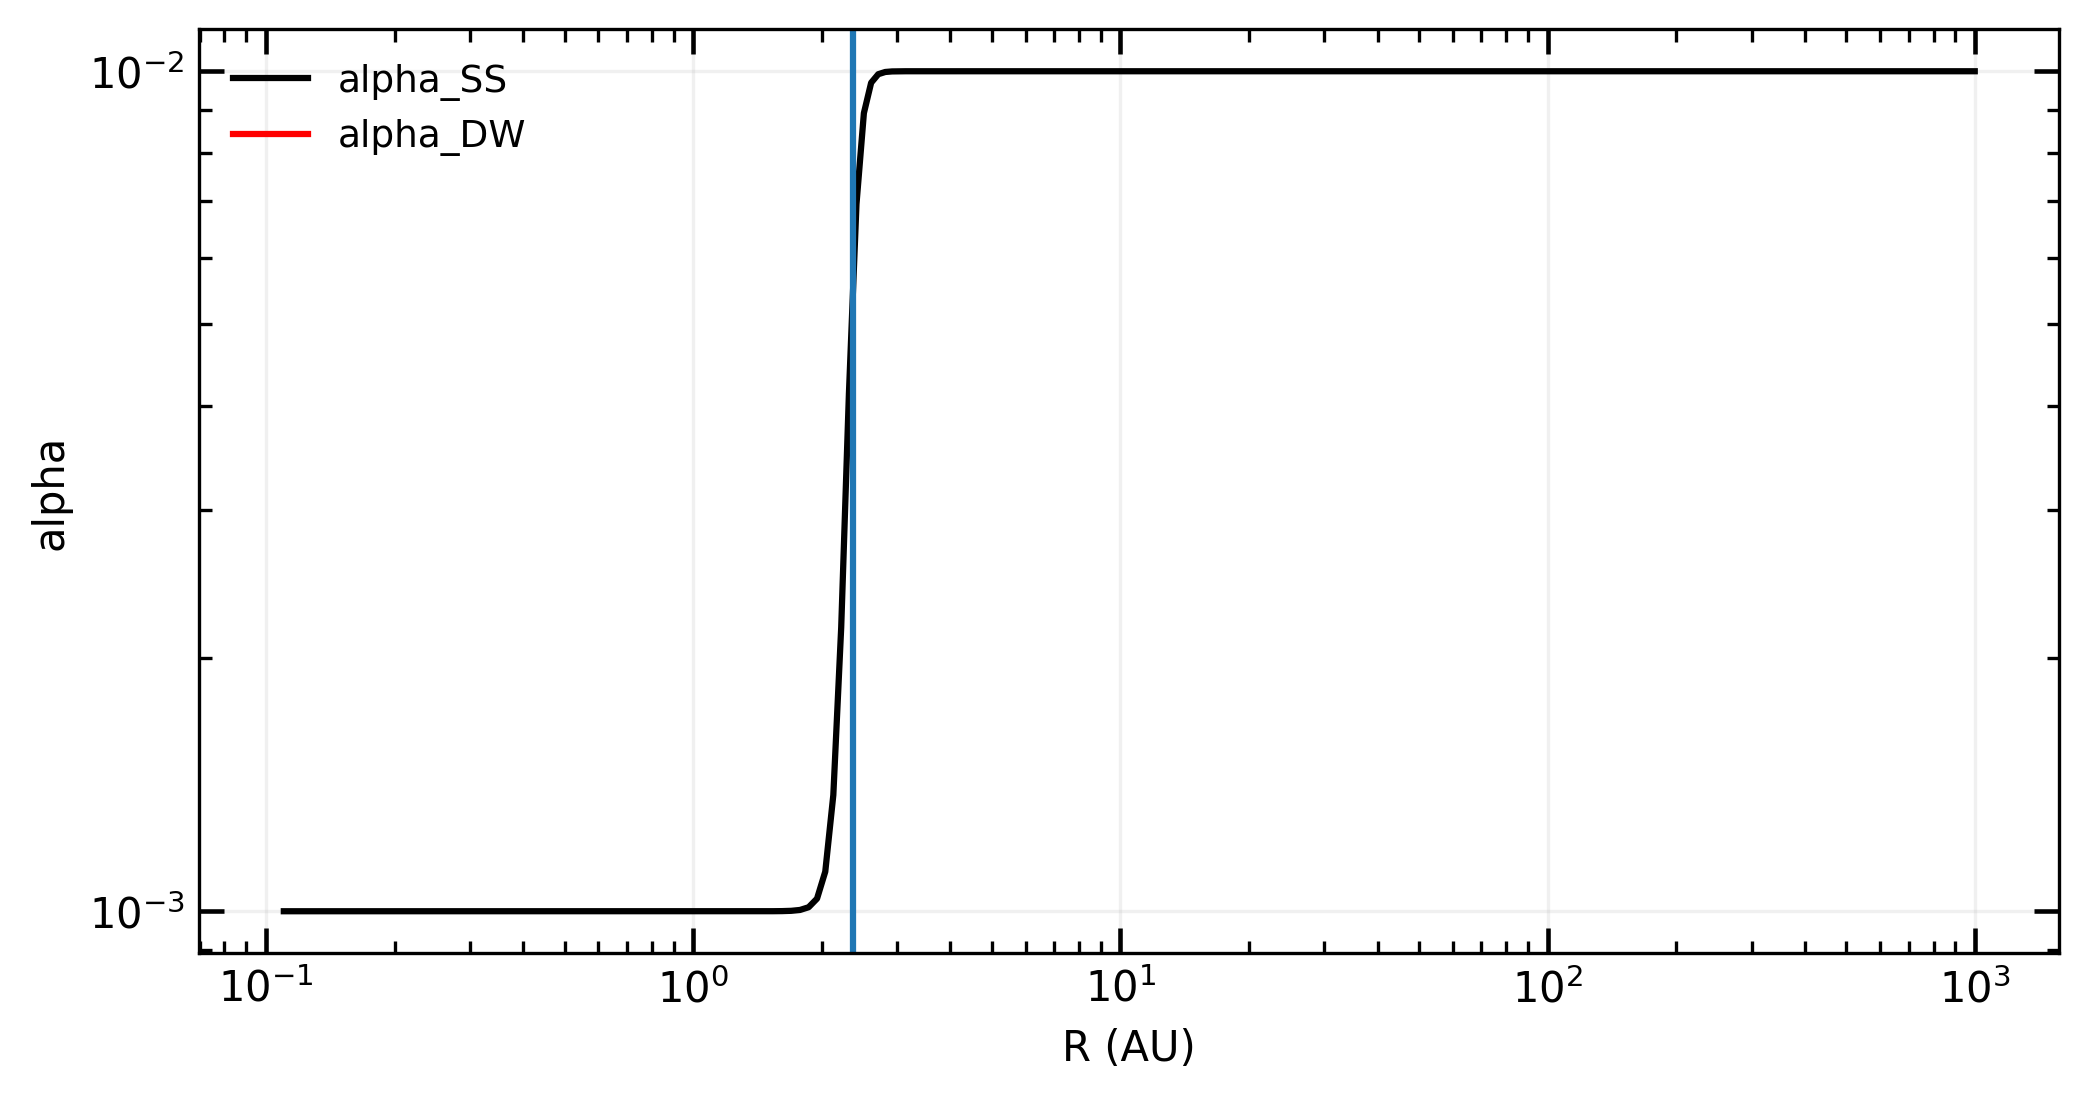

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4), sharex=True, dpi=300, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.loglog(R, eos._alpha_t, '-k', label=f"alpha_SS")
plt.loglog(R, np.ones_like(R)*alpha_DW, '-r', label=f"alpha_DW")
ax.axvline(x = eos._R_dz)
ax.set_ylabel('alpha')
ax.set_xlabel('R (AU)')

ax.legend(frameon=False, fontsize=9, loc="best")

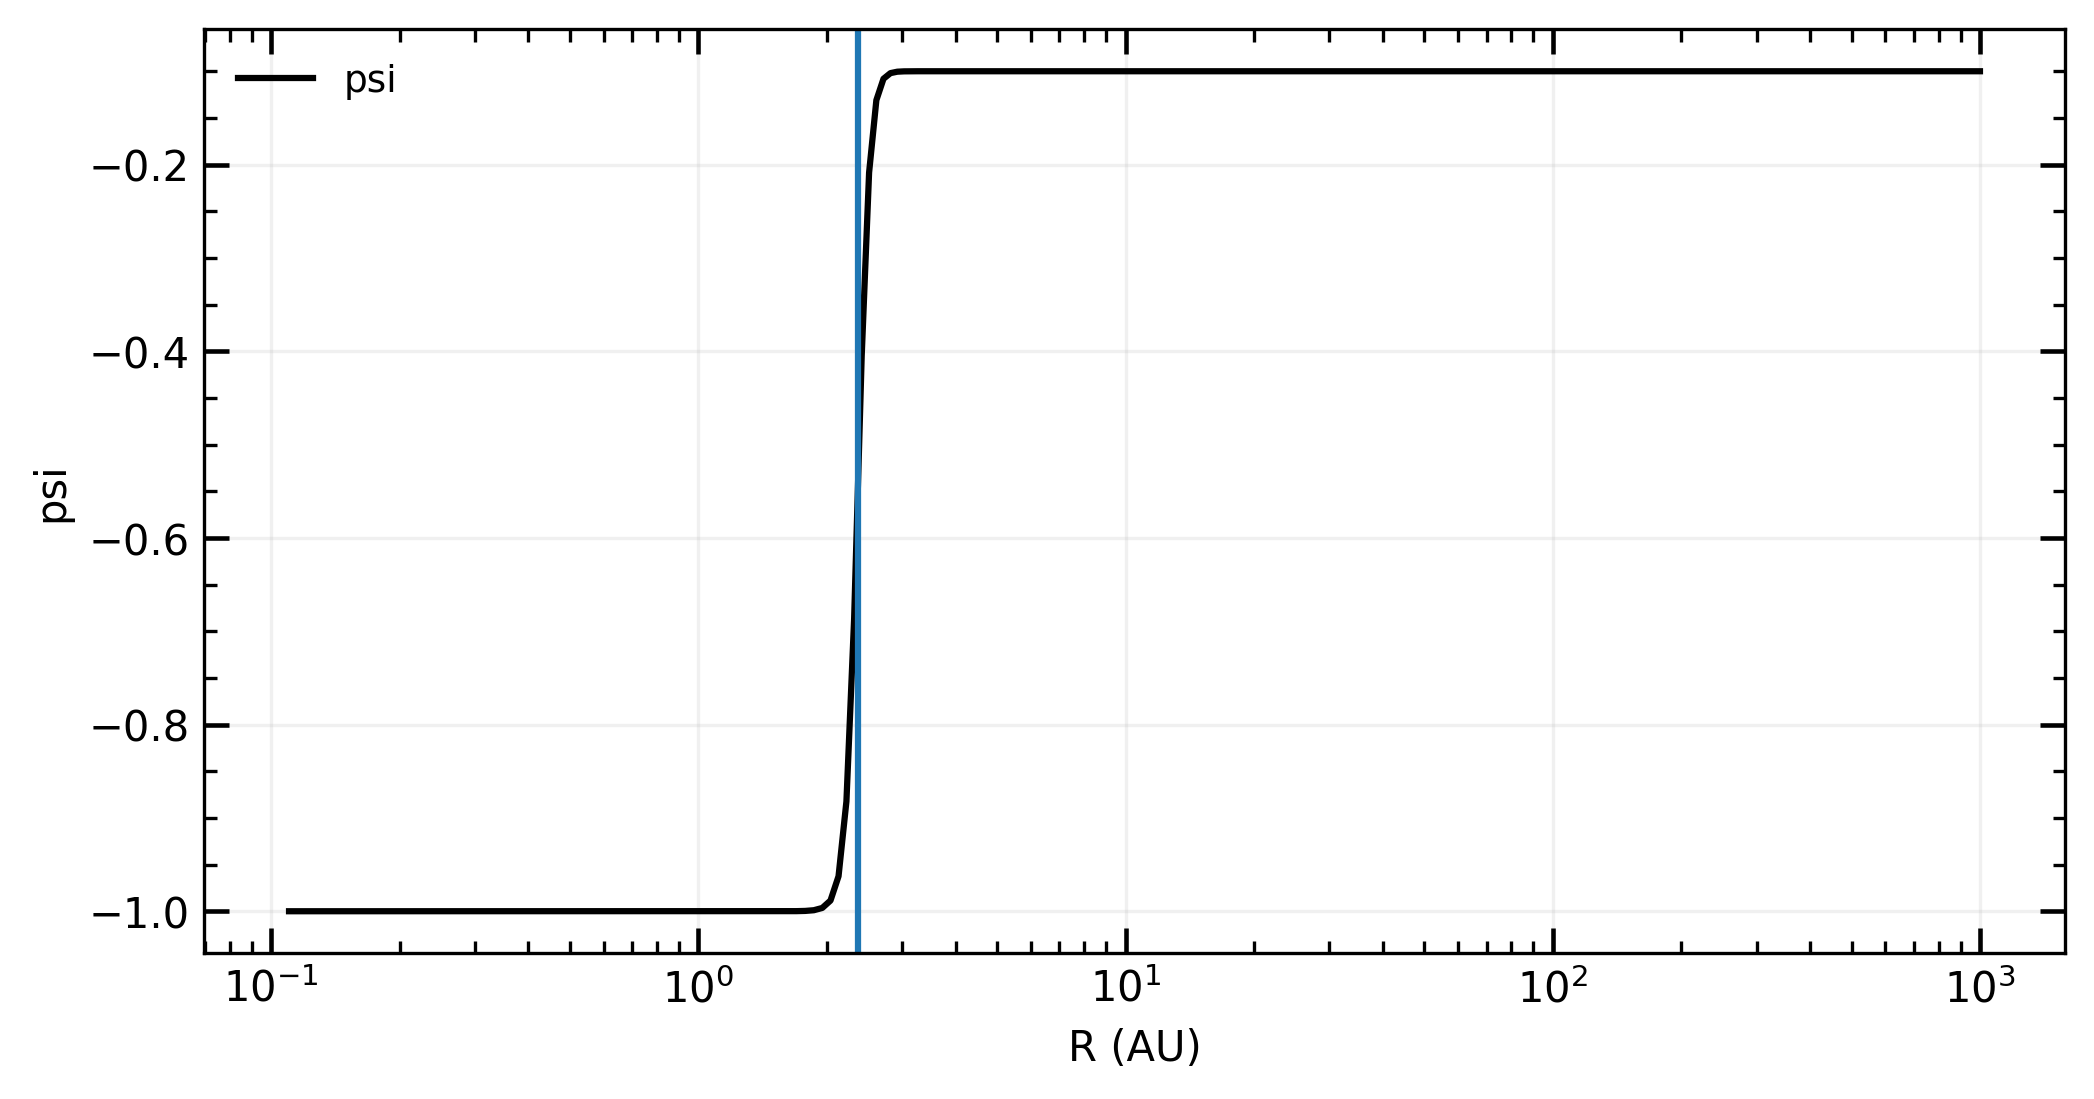

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4), sharex=True, dpi=300, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.semilogx(R, eos._psi, '-k', label=f"psi")
ax.axvline(x = eos._R_dz)
ax.set_ylabel('psi')
ax.set_xlabel('R (AU)')

ax.legend(frameon=False, fontsize=9, loc="best")

# Root Finder

In [17]:
t_initial = 0.0 * u.Myr
t_initial_yr = t_initial.to(u.yr).value 
t_initial_code = t_initial_yr * yr_code  #Convert to code units

t_final = 0.1 * u.Myr
t_final_yr = t_final.to(u.yr).value 
t_final_code = t_final_yr * yr_code  #Convert to code units

Mdisk = 0.1 * Msun 
Rd = 50.0 # u.AU #where disc starts fading out at 0.1 Myr in order to be at 120 AU at 1Myr
Mstar = 1.0 * u.solMass
Rstar = 2.5 * u.solRad
Tstar = 4000.0 * u.K
mu = 2.4
gamma = 1.0

#Reference Values
Mdot_ref = 1e-8
alpha_SS_DZ = 1e-3
alpha_SS_AZ = 1e-2
e_rad = 0.9 
psi_boot = 1.0
lambda_DW_boot = 1/(2*(1 - e_rad)*(3/psi_boot + 1)) + 1

In [18]:
R_in = 0.1   # AU
R_out = 1000.0  # AU — must be >> Rd (91 AU) so the spreading front never reaches the boundary
Ncells = 1000
grid = Grid(R_in, R_out, Ncells, spacing='natural')
R = grid.Rc  # AU

star = SimpleStar(M = Mstar.value ,      #Msun
                  R = Rstar.value,       #Rsun
                  T_eff = Tstar.value,   #K
                  age = t_initial_yr)    #yr

In [19]:
## Section from winds-alpha in run_model.py
# initial guess for Sigma
Sigma_d = Mdisk/(2 * np.pi * (Rd*AU)**2)
xi = 0
Sigma = Sigma_d * (R/Rd)**(xi - gamma) * np.exp(-(R/Rd)**(2 - gamma))

# define an initial disc and gas class to be used later
disc = AccretionDisc(grid, star, eos=None, Sigma=Sigma)
gas_temp = HybridWindModel(psi_boot, lambda_DW_boot)

# scale Sigma by current Mtot just in case Sigma is not quite at the correct value to have the desired Mdisk (which often happens)
Mtot = disc.Mtot()
Sigma[:] *= Mdisk / Mtot

In [20]:
eos = DeadZoneEOS(star, psi , Mdot_ref, evolution_model='ionization', alpha_guess=alpha_SS_DZ)
# eos = IrradiatedEOS(star, alpha_t=alpha_SS_DZ, kappa=Zhu2012, psi=psi, e_rad=e_rad, Tmax=1500)
eos.set_grid(grid)
eos.update(0, Sigma)

disc = AccretionDisc(grid,star,eos,Sigma)
eos._psi

1.0

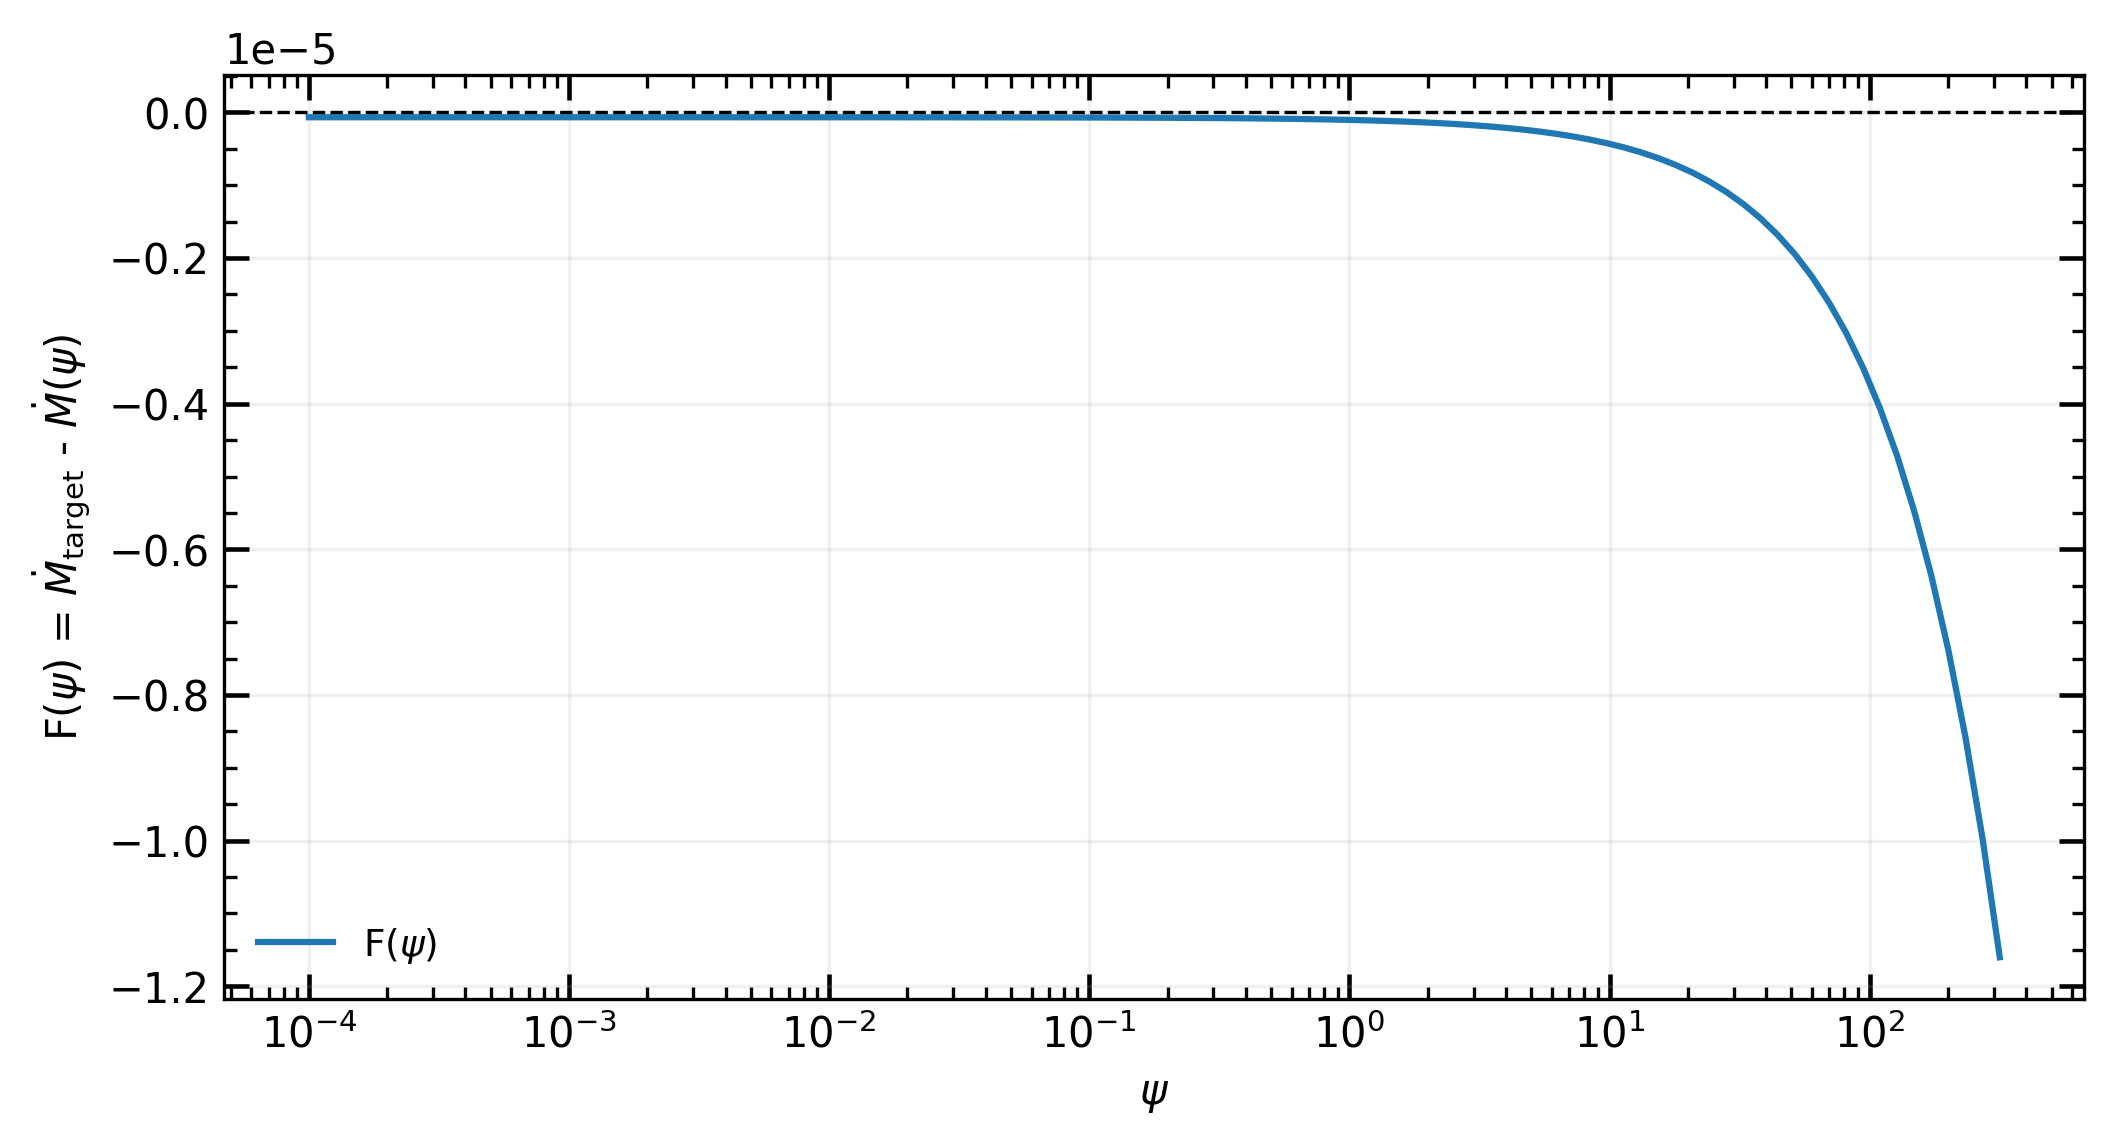

ValueError: psi_from_alpha_SS_Mdot_RootFinder: no sign change in Mdot_target - Mdot(psi) found over psi_space=[1.000e-04, 3.162e+02] 

In [ ]:
from DiscEvolution.solvers import *

psi_solved = psi_from_alpha_SS_Mdot_RootFinder(eos, disc, wind_model, Mdot_ref, verbose=True)
print(psi_solved)